# E2B Example: Parallel Homepage Prototype Studio

This notebook asks a coordinator agent to launch several independent homepage prototypers in parallel across E2B sandboxes. Each worker edits a starter site, serves it, and returns a real preview URL plus a host-captured screenshot.

It defaults to `gpt-5.4-mini` because this example relies on multiple parallel tool calls and benefits a lot from lower planning latency.

The helper keeps the prototype sandboxes running by default so the returned preview URLs stay live until their timeout expires.


In [20]:
import importlib
import os
import subprocess
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "src" / "agents").exists():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src" / "agents").exists():
            repo_root = candidate
            break
        if (candidate / "openai-agents-python-preview" / "src" / "agents").exists():
            repo_root = candidate / "openai-agents-python-preview"
            break

src_root = repo_root / "src"
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

env_path = None
for candidate in [Path.cwd(), *Path.cwd().parents, repo_root, *repo_root.parents]:
    maybe_env = candidate / ".env"
    if maybe_env.exists():
        env_path = maybe_env
        break

if env_path is not None:
    try:
        from dotenv import load_dotenv

        load_dotenv(env_path, override=False)
    except Exception:
        for raw_line in env_path.read_text().splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

required_modules = ["agents", "openai", "e2b", "e2b_code_interpreter"]
missing_modules = [
    module_name for module_name in required_modules if importlib.util.find_spec(module_name) is None
]
if missing_modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_root) + "[e2b]"]
    )

In [21]:
from agents.extensions.sandbox import E2BSandboxType
from examples.sandbox.extensions.e2b.homepage_prototype_parallel import (
    DEFAULT_BRIEF,
    require_credentials,
    run_homepage_parallel_demo,
)

MODEL = os.getenv("OPENAI_MODEL", "gpt-5.4-mini")
SANDBOX_TYPE = E2BSandboxType(os.getenv("E2B_SANDBOX_TYPE", E2BSandboxType.E2B.value))
TEMPLATE = os.getenv("E2B_TEMPLATE") or None
TIMEOUT_SECONDS = int(os.getenv("E2B_TIMEOUT", "900"))
HOMEPAGE_BRIEF = DEFAULT_BRIEF
require_credentials()

In [22]:
payload = await run_homepage_parallel_demo(  # type: ignore[top-level-await]  # noqa: F704
    model=MODEL,
    sandbox_type=SANDBOX_TYPE,
    template=TEMPLATE,
    timeout_seconds=TIMEOUT_SECONDS,
    homepage_brief=HOMEPAGE_BRIEF,
)
payload["selection"]

Apply patch editor failed: exec transport error
Traceback (most recent call last):
  File "/Users/mattbrockman/Code/openai_preview/openai-agents-python-preview/src/agents/extensions/sandbox/e2b/sandbox.py", line 757, in _exec_internal
    self,
          
  File "/Users/mattbrockman/Code/openai_preview/openai-agents-python-preview/src/agents/extensions/sandbox/e2b/sandbox.py", line 333, in _sandbox_run_command
    return await _as_sandbox_api(sandbox).commands.run(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mattbrockman/Code/openai_preview/.venv/lib/python3.12/site-packages/e2b/sandbox_async/commands/command.py", line 235, in run
    return proc if background else await proc.wait()
                                   ^^^^^^^^^^^^^^^^^
  File "/Users/mattbrockman/Code/openai_preview/.venv/lib/python3.12/site-packages/e2b/sandbox_async/commands/command_handle.py", line 172, in wait
    raise self._iteration_exception
  File "/Users/mattbrockman/Code/openai_prev

{'winner_direction': 'product_control_room',
 'shortlist': ['product_control_room',
  'editorial_launch',
  'warm_trust_system'],
 'recommendation': 'Develop product_control_room further. It best matches Orbit’s promise as an AI operations platform by making the homepage feel operational, precise, and credible. The dashboard-led visual system gives the strongest sense of an active live workspace, while still supporting the premium tone and CTA hierarchy. Keep editorial_launch as a close alternate if you want a more brand-led, launch-page feel; use warm_trust_system only if you want to lean harder into approachability and trust over operational authority.'}

In [23]:
try:
    import pandas as pd

    display(pd.DataFrame(payload["prototypes"]))
except Exception:
    print(payload["prototypes"])

[{'direction': 'editorial_launch', 'preview_url': 'https://8765-ikrio7ouqlgo6w6gxcdh2.e2b.app/', 'screenshot_path': '/var/folders/th/bl8nd3wx357f7chyqfb79h6h0000gn/T/openai-agents-homepage-editorial_launch.png', 'summary': 'Built a premium editorial-style Orbit homepage with bold typography, layered ambient gradients, a magazine-like hero, and an evidence-led product preview. The page now centers a crisp narrative around one live workspace, with primary and secondary CTAs and supporting proof content instead of a generic SaaS layout.', 'design_rationale': ['Used oversized headline treatment and tight letter spacing to create a confident launch-page hierarchy.', 'Added layered background glows and glassy panels to give the page depth while keeping it restrained and credible.', 'Replaced generic feature blocks with evidence-led copy, micro-proof cards, and a product-story panel that feels like an editorial cover story.', 'Kept the layout desktop-forward but added mobile-safe stacking, wr

editorial_launch
https://8765-ikrio7ouqlgo6w6gxcdh2.e2b.app/
Built a premium editorial-style Orbit homepage with bold typography, layered ambient gradients, a magazine-like hero, and an evidence-led product preview. The page now centers a crisp narrative around one live workspace, with primary and secondary CTAs and supporting proof content instead of a generic SaaS layout.


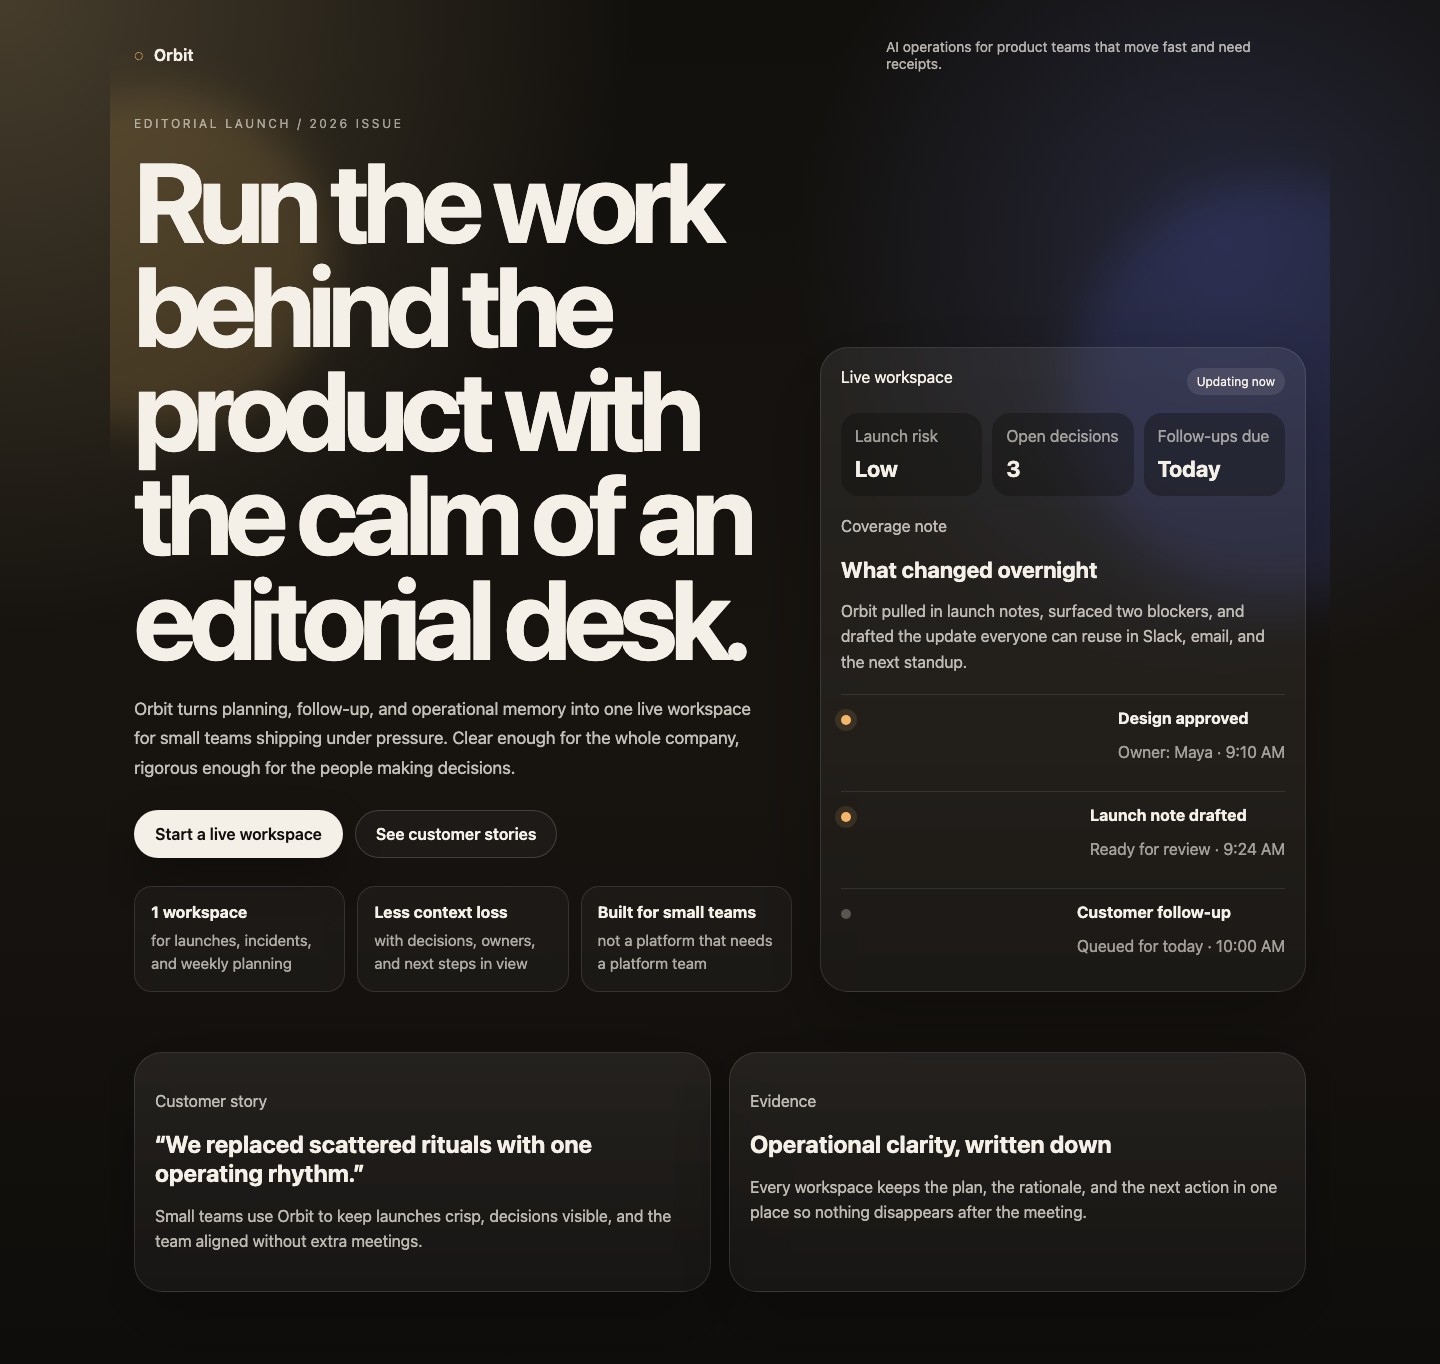

product_control_room
https://8765-im56f3g72v0xjguv5251w.e2b.app/
Built a premium Orbit homepage prototype with a control-room aesthetic: dense hero hierarchy, visible operational dashboard preview, metric strips, workflow states, and trust-focused supporting cards. The page now emphasizes product operations clarity and enterprise credibility while keeping the primary/secondary CTAs prominent.


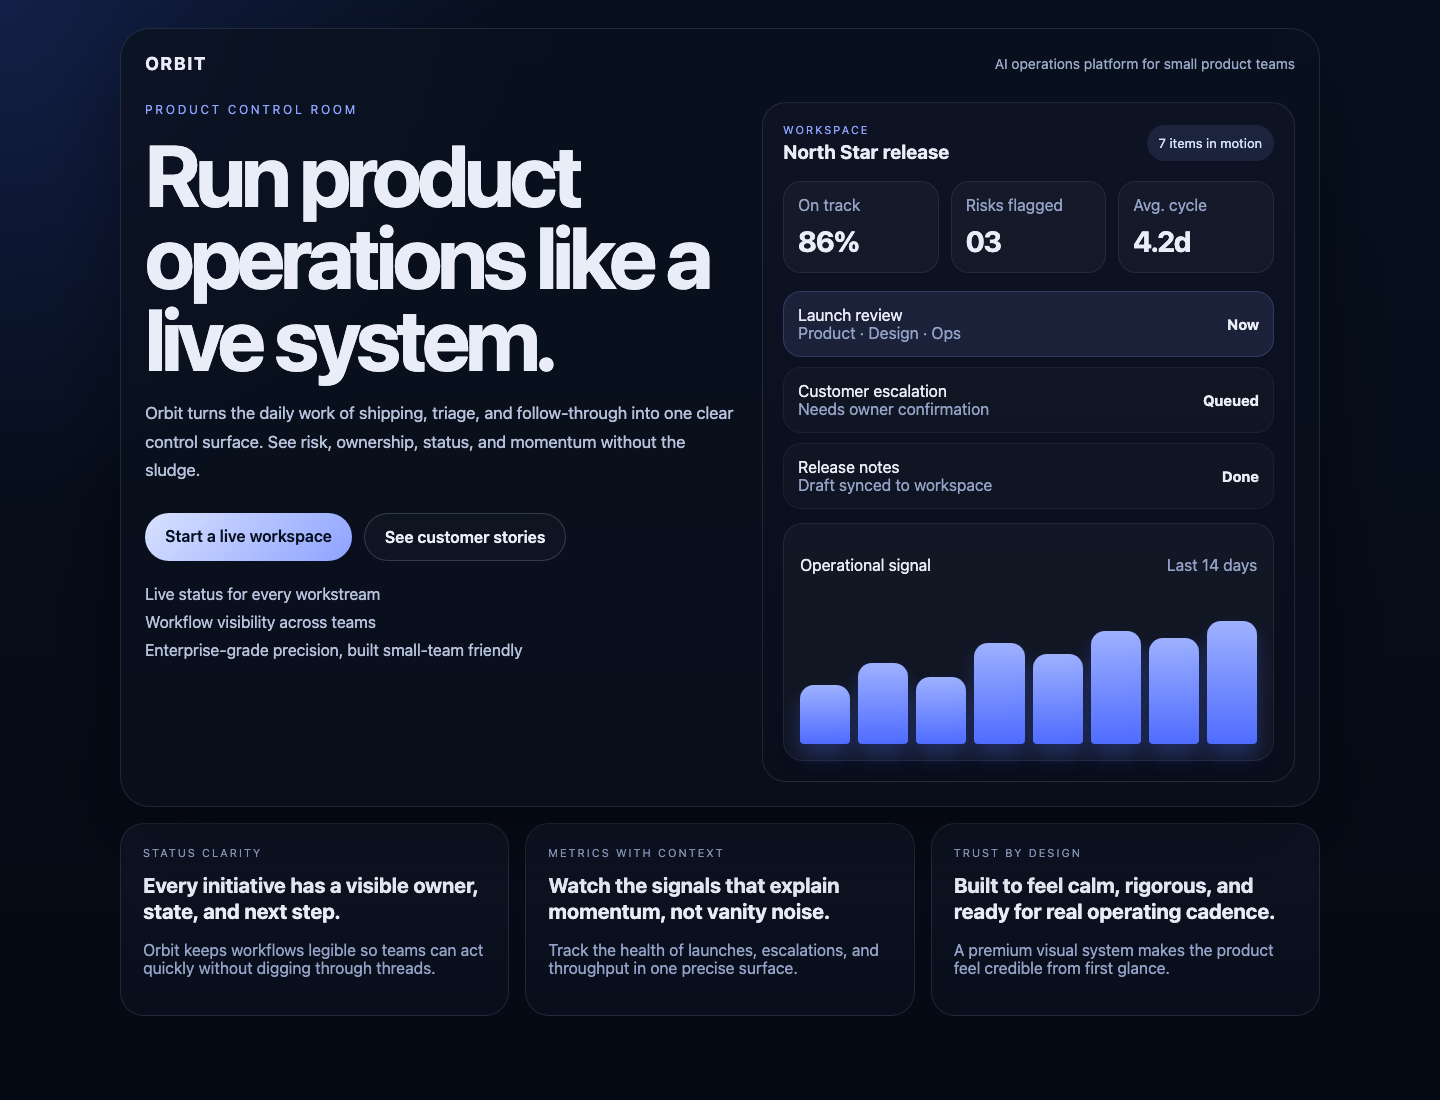

warm_trust_system
https://8765-ir0sbyemsfpnkvy1w53tc.e2b.app/
Built a premium, warm, trust-forward Orbit homepage prototype with a calmer visual language, expressive hero layout, subtle motion, and stronger social proof. The page now centers a live workspace concept with approachable confidence, clear CTA hierarchy, and humanized customer-story content rather than generic SaaS blocks.


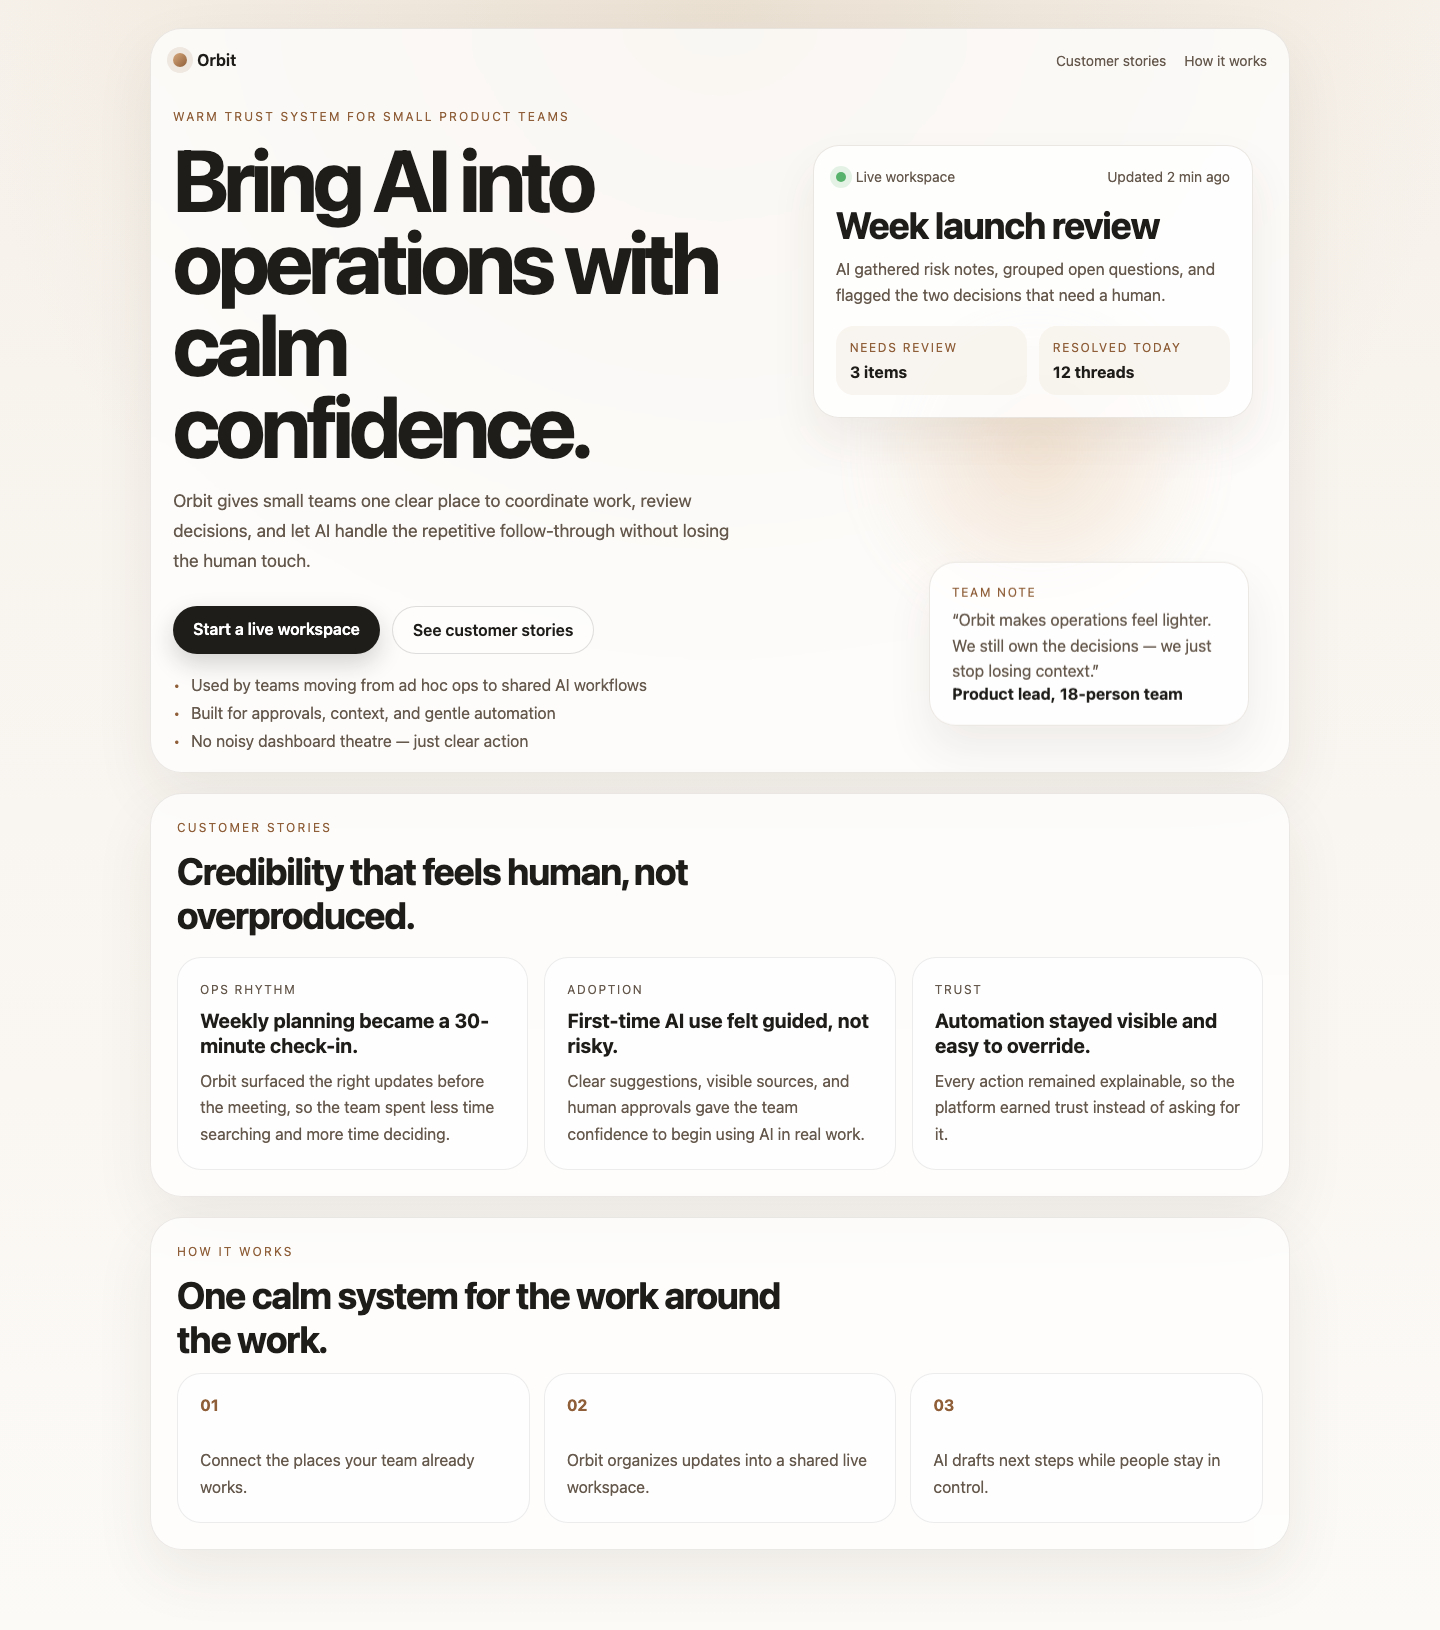

In [24]:
from IPython.display import Image, display

for prototype in payload["prototypes"]:
    print(prototype["direction"])
    print(prototype["preview_url"])
    print(prototype["summary"])
    display(Image(filename=prototype["screenshot_path"]))